# TC3DGS-Inspired Quantized Frame Compression

Apply quantization techniques from **"Temporally Compressed 3D Gaussian Splatting for Dynamic Scenes"** (TC3DGS, arXiv 2412.05700) to compress the **second frame** of a 2D Gaussian splatting fit.

## Pipeline
1. **Multiresolution residual init** → train keyframe (frame 1)
2. **Fine-tune** frame 1 Gaussians to frame 2
3. **TC3DGS compression** on the frame-2 delta:
   - **Gradient-aware mixed-precision quantization**: per-parameter sensitivity $S(\theta)$ from gradient magnitudes assigns bit precision $b \in [b_{min}, b_{max}]$
   - **Learnable step-size quantization (LSQ)**: straight-through estimator with learnable quantization scale, integrated into training
   - **Gaussian masking**: learn a per-Gaussian mask $m_n$ to prune low-importance Gaussians
4. **Compression analysis**: measure storage, PSNR, SSIM, and compare approaches

**Reference:** Javed et al., *Temporally Compressed 3D Gaussian Splatting for Dynamic Scenes*, BMVC 2025.

## 1. Imports and Setup

In [32]:
import sys, math, time, importlib
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.amp import GradScaler, autocast

import lovely_tensors as lt
lt.monkey_patch()

# ── Project path ──────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# ── gsplat_compress library ───────────────────────────────────────────────
import gsplat_compress as gc
from gsplat_compress import (
    GaussianParams, init_gaussians, ortho_camera, render,
    TrainConfig, FinetuneConfig, TrainResult,
    train_keyframe, finetune_frame,
    CodebookConfig, CompressedFrame,
    compute_deltas, build_codebook, finetune_codebook,
    encode_delta_frame, reconstruct_compressed_frame,
    psnr, ssim, mse, keyframe_bytes, delta_frame_bytes,
    raw_frame_bytes, compression_ratio,
    D_FULL, D_EFF, PARAMS_PER_GAUSSIAN_EFF, PARAMS_PER_GAUSSIAN_FULL,
    S_M, S_S, S_Q, S_R, S_O,
)
from gsplat_compress.initializations import multiresolution_residual_2d
from gsplat_compress.training import _enforce_grayscale

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready")

Device: cuda  |  PyTorch 2.10.0+cu128
GPU: NVIDIA A100 80GB PCIe
✅ Imports ready


## 2. Load Target Images (Frame 1 & Frame 2)

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1024, 1024, 2)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,048,576
Loading 2 projections...
Volume shape: (1024, 1024, 2)
Total voxels: 2,097,152
Value range: [9008.1240, 46451.9961]


Frame 1: (1024, 1024), range [0.0000, 1.0000]
Frame 2: (1024, 1024), range [0.0000, 1.0000]


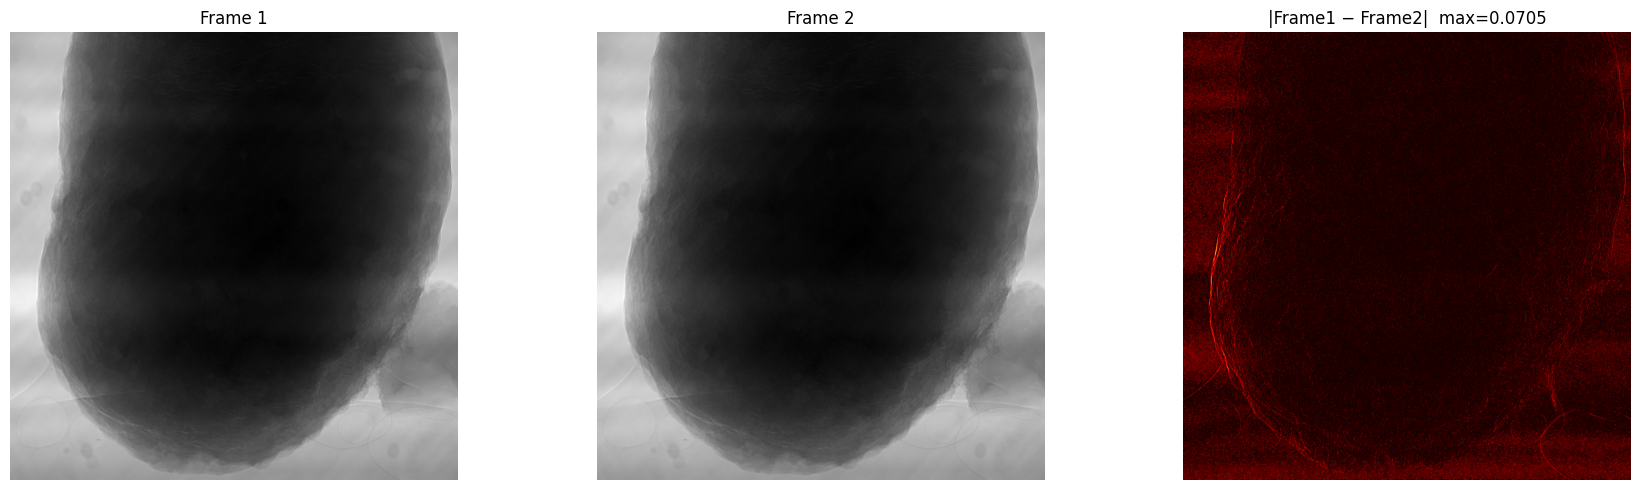

In [33]:
# ── Load dataset ──────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 2
TARGET_SIZE = 1024

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

volume = dataset.get_full_volume()  # (H, W, D)

# ── Frame 1 ──────────────────────────────────────────────────────────────
image_gray = volume[:, :, 0].clone()
img_min, img_max = image_gray.min(), image_gray.max()
image_gray = (image_gray - img_min) / (img_max - img_min + 1e-8)
H, W = image_gray.shape
gt_image = image_gray.unsqueeze(-1).repeat(1, 1, 3).to(device)

# ── Frame 2 ──────────────────────────────────────────────────────────────
image_gray2 = volume[:, :, 1].clone()
img_min2, img_max2 = image_gray2.min(), image_gray2.max()
image_gray2 = (image_gray2 - img_min2) / (img_max2 - img_min2 + 1e-8)
gt_image2 = image_gray2.unsqueeze(-1).repeat(1, 1, 3).to(device)

print(f"Frame 1: ({H}, {W}), range [{image_gray.min():.4f}, {image_gray.max():.4f}]")
print(f"Frame 2: ({H}, {W}), range [{image_gray2.min():.4f}, {image_gray2.max():.4f}]")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_gray.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Frame 1'); axes[0].axis('off')
axes[1].imshow(image_gray2.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Frame 2'); axes[1].axis('off')
diff_np = np.abs(image_gray.cpu().numpy() - image_gray2.cpu().numpy())
axes[2].imshow(diff_np, cmap='hot', vmin=0, vmax=diff_np.max())
axes[2].set_title(f'|Frame1 − Frame2|  max={diff_np.max():.4f}'); axes[2].axis('off')
plt.tight_layout(); plt.show()

## 3. Camera Setup + Multiresolution Residual Initialization

Running multiresolution residual init …
✅ MR init done → 100,000 Gaussians

 Stage    N Gaussians    σ (px)
----------------------------------
1 (coarse)         35,000      12.0  [uniform grid]
         2         32,500       6.0  [residual-driven]
         3         32,500       3.0  [residual-driven]


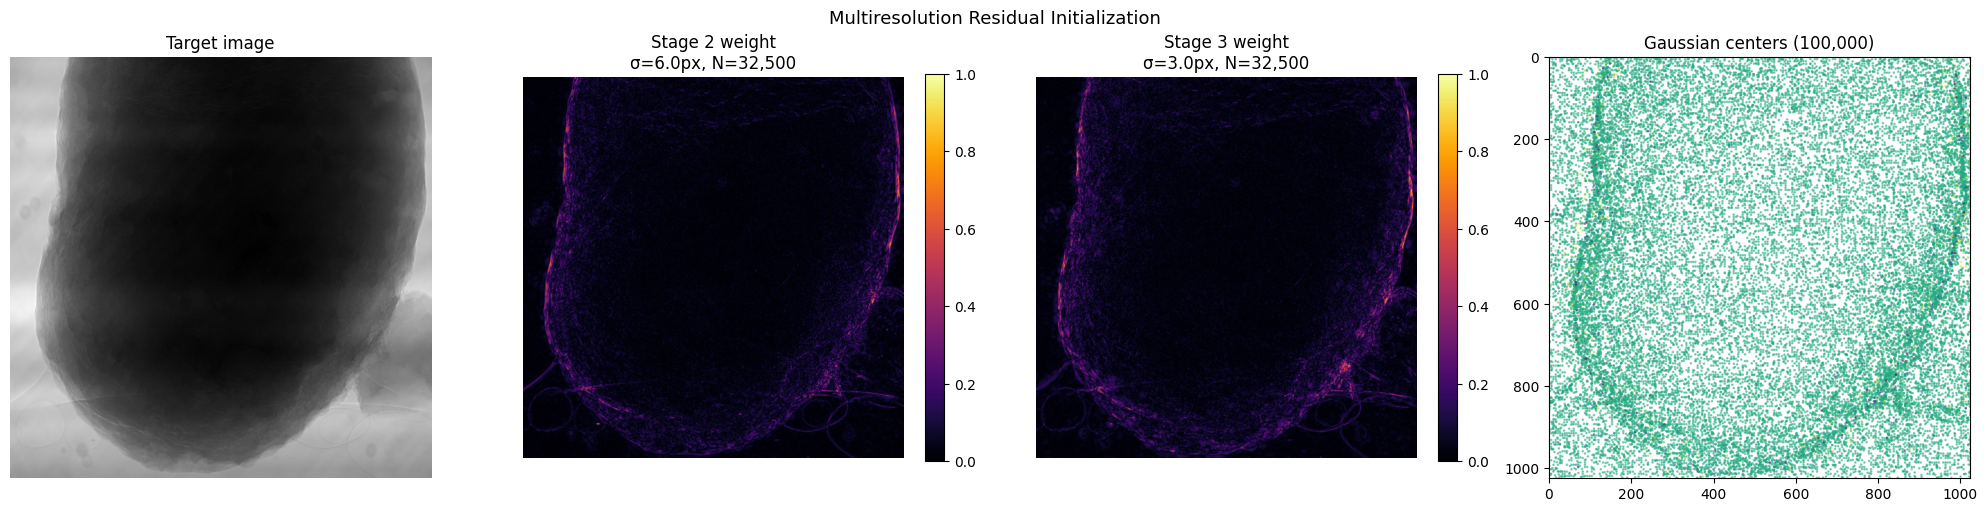

In [ ]:
# ── Orthographic camera ───────────────────────────────────────────────────
K_cam, viewmat = ortho_camera(device)
USE_FP16 = True

# ── Multiresolution residual initialization ───────────────────────────────
N_POINTS = 100_000
N_STAGES = 3
COARSE_FRAC = 0.35
ETA = 0.30
INIT_SCALE = 3.0youtyout
AMP_ITERS = 150
AMP_LR = 0.05

print("Running multiresolution residual init …")
params_mr, stage_info = multiresolution_residual_2d(
    image_gray, N_POINTS, device,
    n_stages=N_STAGES,
    coarse_fraction=COARSE_FRAC,
    eta=ETA,
    init_scale_px=INIT_SCALE,
    init_opacity=0.6,
    amplitude_iters=AMP_ITERS,
    amplitude_lr=AMP_LR,
    seed=42,
    return_stages=True,
)
print(f"✅ MR init done → {params_mr.n_gaussians:,} Gaussians")

# ── Stage diagnostics ─────────────────────────────────────────────────────
print(f"\n{'Stage':>6}  {'N Gaussians':>13}  {'σ (px)':>8}")
print("-" * 34)
n1 = N_POINTS - sum(s["n_gaussians"] for s in stage_info)
s1 = INIT_SCALE * (2 ** (N_STAGES - 1))
print(f"{'1 (coarse)':>10}  {n1:>13,}  {s1:>8.1f}  [uniform grid]")
for si in stage_info:
    print(f"  {si['stage']:>8d}  {si['n_gaussians']:>13,}  {si['scale_px']:>8.1f}  [residual-driven]")

# ── Visualize ─────────────────────────────────────────────────────────────
n_extra = len(stage_info)
fig, axes = plt.subplots(1, n_extra + 2, figsize=(5 * (n_extra + 2), 5))
axes[0].imshow(image_gray.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target image'); axes[0].axis('off')
for i, si in enumerate(stage_info):
    weight_np = si['weight_map'].numpy()
    ax = axes[i + 1]
    im = ax.imshow(weight_np, cmap='inferno', vmin=0, vmax=1)
    ax.set_title(f"Stage {si['stage']} weight\nσ={si['scale_px']:.1f}px, N={si['n_gaussians']:,}")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
means_np = params_mr.means.detach().cpu().numpy()
opac_np = torch.sigmoid(params_mr.opacities).detach().cpu().numpy()
n_show = min(30_000, means_np.shape[0])
idx_show = np.random.default_rng(0).choice(means_np.shape[0], n_show, replace=False)
axes[-1].scatter(means_np[idx_show, 0], means_np[idx_show, 1],
                 c=opac_np[idx_show], cmap='viridis', s=0.8, alpha=0.5)
axes[-1].set_xlim(0, W); axes[-1].set_ylim(H, 0)
axes[-1].set_title(f'Gaussian centers ({params_mr.n_gaussians:,})')
axes[-1].set_aspect('equal')
plt.suptitle('Multiresolution Residual Initialization', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Train Keyframe (Frame 1)

Training keyframe: 30000 iters, N=100,000, fp16=True
[    0/30000]  loss=0.000028  PSNR=45.50 dB  N=100,000
  ↳ [densify @ 500]  pruned=0  split=125  N=100,125
  ↳ [densify @ 1000]  pruned=0  split=83  N=100,208
  ↳ [densify @ 1500]  pruned=0  split=76  N=100,284
[ 2000/30000]  loss=0.000024  PSNR=46.16 dB  N=100,284
  ↳ [densify @ 2000]  pruned=0  split=68  N=100,352
  ↳ [densify @ 2500]  pruned=0  split=76  N=100,428
  ↳ [densify @ 3000]  pruned=0  split=71  N=100,499
  ↳ [densify @ 3500]  pruned=0  split=72  N=100,571
[ 4000/30000]  loss=0.000022  PSNR=46.60 dB  N=100,571
  ↳ [densify @ 4000]  pruned=0  split=85  N=100,656
  ↳ [densify @ 4500]  pruned=0  split=89  N=100,745
  ↳ [densify @ 5000]  pruned=0  split=80  N=100,825
  ↳ [densify @ 5500]  pruned=0  split=77  N=100,902
[ 6000/30000]  loss=0.000020  PSNR=46.91 dB  N=100,902
  ↳ [densify @ 6000]  pruned=0  split=78  N=100,980
  ↳ [densify @ 6500]  pruned=0  split=104  N=101,084
  ↳ [densify @ 7000]  pruned=0  split=74  N=101,15

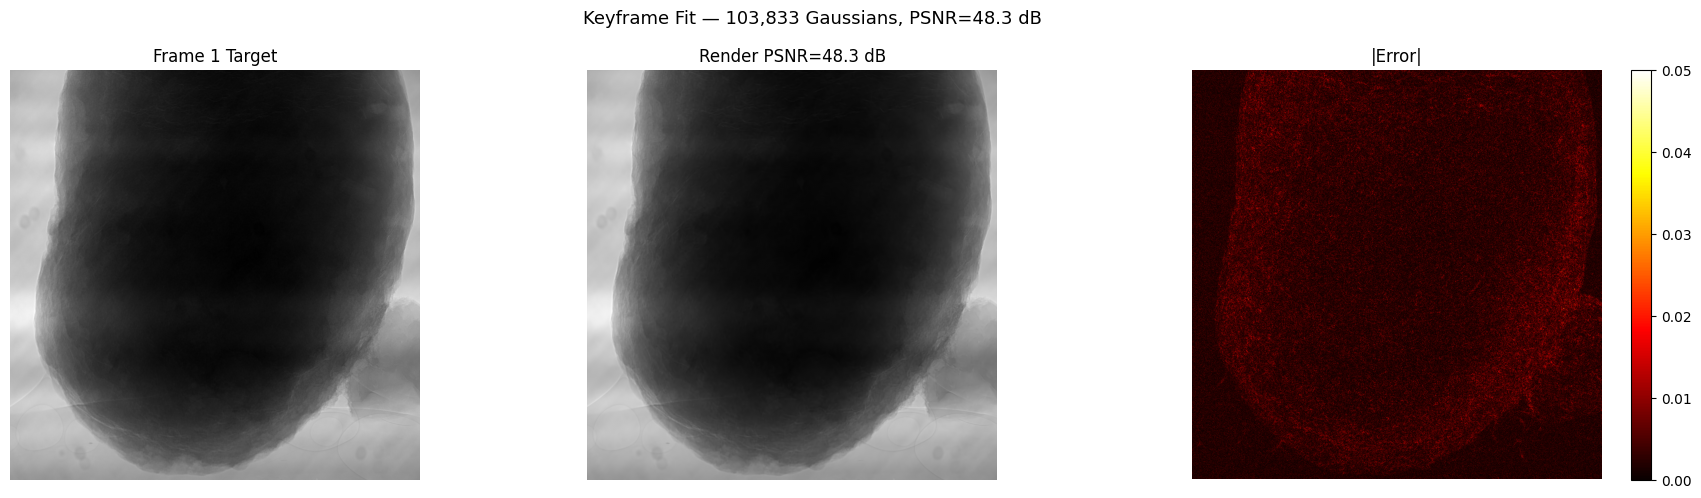


Keyframe: 103,833 Gaussians, PSNR=48.34 dB, size=1.87 MB


In [52]:
# ── Training config ───────────────────────────────────────────────────────
train_cfg = TrainConfig(
    num_iterations=30_000,
    use_fp16=USE_FP16,
    log_interval=2000,
    lr_means=1e-3,
    lr_scales=5e-3,
    lr_quats=1e-3,
    lr_rgbs=1e-2,
    lr_opacities=5e-2,
    densify_from=500,
    densify_interval=500,
    densify_until=25_000,
    prune_opacity_thresh=0.002,
    split_scale_thresh=20.0,
)

train_result = train_keyframe(params_mr, gt_image, viewmat, K_cam, W, H, train_cfg, verbose=True)
params = train_result.params

# ── Quick visual ──────────────────────────────────────────────────────────
with torch.no_grad():
    final_render, final_alpha, _ = render(
        params.means, params.log_scales, params.quats,
        params.rgbs, params.opacities, viewmat, K_cam, W, H,
    )

final_np = np.clip(final_render[:, :, 0].cpu().numpy(), 0, 1)
target_np = gt_image[:, :, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(target_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Frame 1 Target'); axes[0].axis('off')
axes[1].imshow(final_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Render PSNR={train_result.psnr_history[-1]:.1f} dB'); axes[1].axis('off')
err = np.abs(final_np - target_np)
im = axes[2].imshow(err, cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('|Error|'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.suptitle(f'Keyframe Fit — {params.n_gaussians:,} Gaussians, '
             f'PSNR={train_result.psnr_history[-1]:.1f} dB', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nKeyframe: {params.n_gaussians:,} Gaussians, "
      f"PSNR={train_result.psnr_history[-1]:.2f} dB, "
      f"size={keyframe_bytes(params.n_gaussians, USE_FP16)/1e6:.2f} MB")

## 5. Fine-Tune Frame 1 → Frame 2

Use the fitted frame-1 Gaussians as a warm start and fine-tune to frame 2.
This produces the "teacher" signal for delta compression.

Fine-tuning frame: 10000 iters, N=103,833, lr_scale=0.3
  [    0/10000]  loss=0.000031  PSNR=45.07 dB


  [ 2000/10000]  loss=0.000017  PSNR=47.79 dB
  [ 4000/10000]  loss=0.000016  PSNR=47.88 dB
  [ 6000/10000]  loss=0.000016  PSNR=47.94 dB
  [ 8000/10000]  loss=0.000016  PSNR=47.99 dB
  [ 9999/10000]  loss=0.000016  PSNR=48.03 dB
✅ Fine-tune done in 54.0s  PSNR=48.03 dB


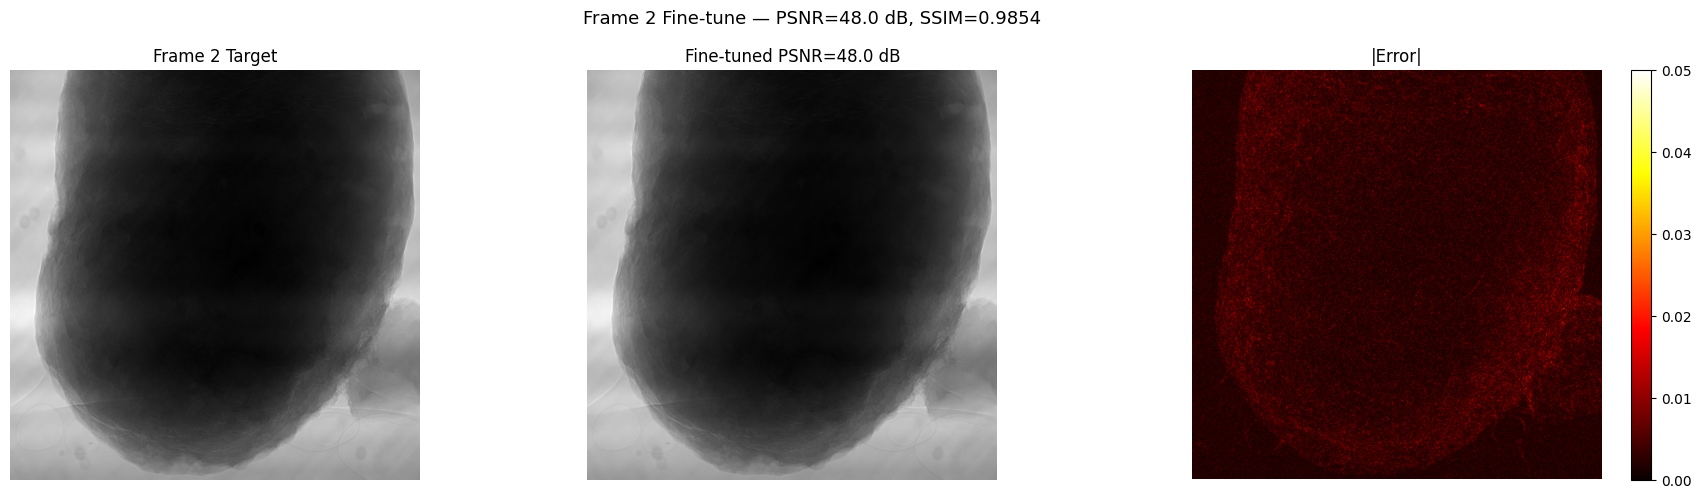


Fine-tune upper bound: PSNR=48.03 dB, SSIM=0.9854
Gaussians: 103,833


In [53]:
# ── Snapshot frame-1 params ───────────────────────────────────────────────
snap1 = params.detach_clone()
N_G = snap1.n_gaussians

# ── Fine-tune to frame 2 ─────────────────────────────────────────────────
ft_cfg = FinetuneConfig(
    num_iterations=10_000,
    use_fp16=USE_FP16,
    log_interval=2000,
    lr_scale=0.3,
)

ft_result = finetune_frame(snap1, gt_image2, viewmat, K_cam, W, H, ft_cfg, verbose=True)
snap2 = ft_result.params.detach_clone()

# ── Evaluate ──────────────────────────────────────────────────────────────
with torch.no_grad():
    render_ft2, _, _ = render(snap2.means, snap2.log_scales, snap2.quats,
                               snap2.rgbs, snap2.opacities, viewmat, K_cam, W, H)
target2_np = image_gray2.cpu().numpy()
ft_np = np.clip(render_ft2[:, :, 0].cpu().numpy(), 0, 1)
ft_psnr = psnr(ft_np, target2_np)
ft_ssim = ssim(ft_np, target2_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(target2_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Frame 2 Target'); axes[0].axis('off')
axes[1].imshow(ft_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Fine-tuned PSNR={ft_psnr:.1f} dB'); axes[1].axis('off')
err_ft = np.abs(ft_np - target2_np)
im = axes[2].imshow(err_ft, cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('|Error|'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.suptitle(f'Frame 2 Fine-tune — PSNR={ft_psnr:.1f} dB, SSIM={ft_ssim:.4f}', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nFine-tune upper bound: PSNR={ft_psnr:.2f} dB, SSIM={ft_ssim:.4f}")
print(f"Gaussians: {N_G:,}")

## 6. Baseline: Codebook Delta Compression (VQ only)

For reference, run the existing codebook-based compression from the library.

In [54]:
# ── Baseline: codebook VQ compression ─────────────────────────────────────
K_CB_BASELINE = 2048

cb_baseline_cfg = CodebookConfig(
    n_clusters=K_CB_BASELINE,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=2000,
    finetune_lr=5e-4,
    use_fp16=USE_FP16,
)

compressed_baseline, rec_baseline = encode_delta_frame(
    snap1, snap2, gt_image2, viewmat, K_cam, W, H, cb_baseline_cfg, verbose=True,
)

with torch.no_grad():
    rend_baseline, _, _ = render(rec_baseline.means, rec_baseline.log_scales,
                                  rec_baseline.quats, rec_baseline.rgbs,
                                  rec_baseline.opacities, viewmat, K_cam, W, H)
baseline_np = np.clip(rend_baseline[:, :, 0].cpu().numpy(), 0, 1)
baseline_psnr = psnr(baseline_np, target2_np)
baseline_ssim = ssim(baseline_np, target2_np)
baseline_bytes = compressed_baseline.storage_bytes(USE_FP16)

print(f"\n{'='*55}")
print(f"  Baseline VQ (K={K_CB_BASELINE})")
print(f"{'='*55}")
print(f"  PSNR:  {baseline_psnr:.2f} dB")
print(f"  SSIM:  {baseline_ssim:.4f}")
print(f"  Delta: {baseline_bytes['total_bytes']/1e3:.1f} kB")
print(f"{'='*55}")

Delta matrix: 103,833 × 14


K-means done: K=2048, cluster sizes min=0 max=45597
Codebook fine-tune: K=2048, 2000 iters, lr=0.0005
  [    0/2000]  loss=0.000034  PSNR=44.63 dB
  [  500/2000]  loss=0.000020  PSNR=47.03 dB
  [ 1000/2000]  loss=0.000019  PSNR=47.16 dB
  [ 1500/2000]  loss=0.000019  PSNR=47.20 dB
  [ 1999/2000]  loss=0.000019  PSNR=47.21 dB
✅ Codebook fine-tune done in 34.3s  PSNR=47.21 dB

  Baseline VQ (K=2048)
  PSNR:  47.21 dB
  SSIM:  0.9836
  Delta: 175.5 kB


## 7. TC3DGS Technique 1: Gradient-Aware Mixed-Precision Quantization

From Sec. 3.2.2 of TC3DGS: compute **per-parameter sensitivity** from gradient magnitudes:

$$S(\theta) = \frac{1}{\sum_k N_k} \sum_{k=1}^{K} \left| \frac{\partial Q_k}{\partial \theta} \right|$$

Then normalize to $\gamma \in [0,1]$ and assign bit precision:

$$b = \lfloor \gamma \cdot (b_{\max} - b_{\min}) \rfloor + b_{\min}$$

Parameters with high sensitivity get more bits; low-impact parameters get fewer bits.
We apply this to the **delta vector** between frame 1 and frame 2.

In [55]:
# ══════════════════════════════════════════════════════════════════════════
# TC3DGS helper functions: gradient sensitivity + mixed-precision quantize
# ══════════════════════════════════════════════════════════════════════════

def compute_gradient_sensitivity(
    base: GaussianParams,
    delta_params: GaussianParams,
    gt_image: torch.Tensor,
    viewmat: torch.Tensor,
    K_cam: torch.Tensor,
    W: int, H: int,
    n_accumulate: int = 5,
    use_fp16: bool = True,
) -> dict[str, torch.Tensor]:
    """Per-parameter gradient sensitivity (TC3DGS Sec. 3.2.2).

    S(θ) = (1/K) Σ_k |∂L_k / ∂θ|

    Computes sensitivity at the **base** parameters against *gt_image*.
    This measures which parameters need the most adjustment to reach the
    target frame — exactly the information needed to allocate bit precision
    for the delta.

    Returns dict with keys: means [N,3], log_scales [N,3], quats [N,4],
    rgbs [N,3], opacities [N].
    """
    device = base.device

    # Use BASE params (significant loss → meaningful gradients)
    means = base.means.detach().float().clone().requires_grad_(True)
    log_scales = base.log_scales.detach().float().clone().requires_grad_(True)
    quats = base.quats.detach().float().clone().requires_grad_(True)
    rgbs = base.rgbs.detach().float().clone().requires_grad_(True)
    opacities = base.opacities.detach().float().clone().requires_grad_(True)
    gt_fp32 = gt_image.float()

    all_params = [means, log_scales, quats, rgbs, opacities]
    mse_fn = torch.nn.MSELoss()

    # Accumulate |grad| over K forward passes (no autocast — need fp32 grads)
    accum = [torch.zeros_like(p) for p in all_params]

    for _ in range(n_accumulate):
        for p in all_params:
            if p.grad is not None:
                p.grad.zero_()

        rendered, _, _ = render(means, log_scales, quats, rgbs, opacities,
                                viewmat, K_cam, W, H)
        loss = mse_fn(rendered, gt_fp32)
        loss.backward()

        for i, p in enumerate(all_params):
            if p.grad is not None:
                accum[i] += p.grad.abs()

    # Average over accumulation steps
    for i in range(len(accum)):
        accum[i] /= n_accumulate

    torch.cuda.synchronize()
    return {
        'means': accum[0],
        'log_scales': accum[1],
        'quats': accum[2],
        'rgbs': accum[3],
        'opacities': accum[4],
    }


def mixed_precision_quantize(
    delta: torch.Tensor,        # [N, D]
    sensitivity: torch.Tensor,  # [N, D]
    b_min: int = 4,
    b_max: int = 8,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Per-element mixed-precision uniform quantization (TC3DGS Sec. 3.2.2).

    1. Normalize sensitivity per column → γ ∈ [0, 1]
    2. Assign bits: b = floor(γ · (b_max − b_min)) + b_min
    3. Uniform-quantize each column at per-element bit depth

    Returns (quantized_delta [N,D], bit_map [N,D] int).
    """
    # ── Assign bits from sensitivity ──────────────────────────────────────
    s_min = sensitivity.min(dim=0, keepdim=True).values
    s_max = sensitivity.max(dim=0, keepdim=True).values
    gamma = (sensitivity - s_min) / (s_max - s_min + 1e-10)

    bit_map = (torch.floor(gamma * (b_max - b_min)) + b_min).int().clamp(b_min, b_max)

    # ── Quantize each column at its assigned bit depths ───────────────────
    N, D = delta.shape
    quantized = torch.zeros_like(delta)

    for d in range(D):
        col = delta[:, d]
        col_min, col_max = col.min(), col.max()
        if col_max - col_min < 1e-10:
            quantized[:, d] = col
            continue
        for b in range(b_min, b_max + 1):
            mask = (bit_map[:, d] == b)
            if not mask.any():
                continue
            n_levels = 2 ** b
            vals = col[mask]
            norm = (vals - col_min) / (col_max - col_min)
            q_norm = torch.round(norm * (n_levels - 1)) / (n_levels - 1)
            quantized[:, d] = quantized[:, d].clone()
            quantized[:, d][mask] = q_norm * (col_max - col_min) + col_min

    return quantized, bit_map


print("✅ compute_gradient_sensitivity & mixed_precision_quantize defined")

✅ compute_gradient_sensitivity & mixed_precision_quantize defined


In [56]:
# ── Quick check: what is the loss at base params vs frame 2? ──────────────
with torch.no_grad():
    rend_base, _, _ = render(snap1.means, snap1.log_scales, snap1.quats,
                              snap1.rgbs, snap1.opacities, viewmat, K_cam, W, H)
    base_loss = F.mse_loss(rend_base, gt_image2)
    base_psnr = -10 * math.log10(base_loss.item() + 1e-10)
print(f"Base (snap1) vs Frame 2: loss={base_loss.item():.6e}, PSNR={base_psnr:.2f} dB")

# ── Compute sensitivities ─────────────────────────────────────────────────
print("\nComputing per-parameter gradient sensitivities…")
t0 = time.time()

delta_params = GaussianParams(
    means=(snap2.means - snap1.means).detach().clone().to(device),
    log_scales=(snap2.log_scales - snap1.log_scales).detach().clone().to(device),
    quats=(snap2.quats - snap1.quats).detach().clone().to(device),
    rgbs=(snap2.rgbs - snap1.rgbs).detach().clone().to(device),
    opacities=(snap2.opacities - snap1.opacities).detach().clone().to(device),
)

sensitivities = compute_gradient_sensitivity(
    snap1, delta_params, gt_image2, viewmat, K_cam, W, H,
    n_accumulate=5, use_fp16=USE_FP16,
)
torch.cuda.synchronize()
print(f"Done in {time.time()-t0:.1f}s")

# ── Print sensitivity statistics ──────────────────────────────────────────
print(f"\n{'Parameter':<14} {'Mean S':>12} {'Max S':>12} {'Min S':>12}")
print("-" * 55)
for name, s in sensitivities.items():
    print(f"  {name:<12} {s.mean().item():>12.2e} {s.max().item():>12.2e} {s.min().item():>12.2e}")
print(f"\nTotal sensitivity spread (max/min across all): "
      f"{max(s.max().item() for s in sensitivities.values()):.2e} / "
      f"{min(s.min().item() for s in sensitivities.values()):.2e}")

Base (snap1) vs Frame 2: loss=3.110700e-05, PSNR=45.07 dB

Computing per-parameter gradient sensitivities…
Done in 0.0s

Parameter            Mean S        Max S        Min S
-------------------------------------------------------
  means            1.58e-10     1.70e-07     0.00e+00
  log_scales       2.12e-09     7.93e-07     0.00e+00
  quats            9.14e-10     2.32e-06     0.00e+00
  rgbs             2.61e-09     7.74e-07     0.00e+00
  opacities        1.46e-09     5.53e-07     0.00e+00

Total sensitivity spread (max/min across all): 2.32e-06 / 0.00e+00



Mixed-Precision Quantization (b=[4,8]):
  Average bits/param:  4.00
  PSNR:                45.81 dB
  SSIM:                0.9826
  Delta storage:       415.4 kB


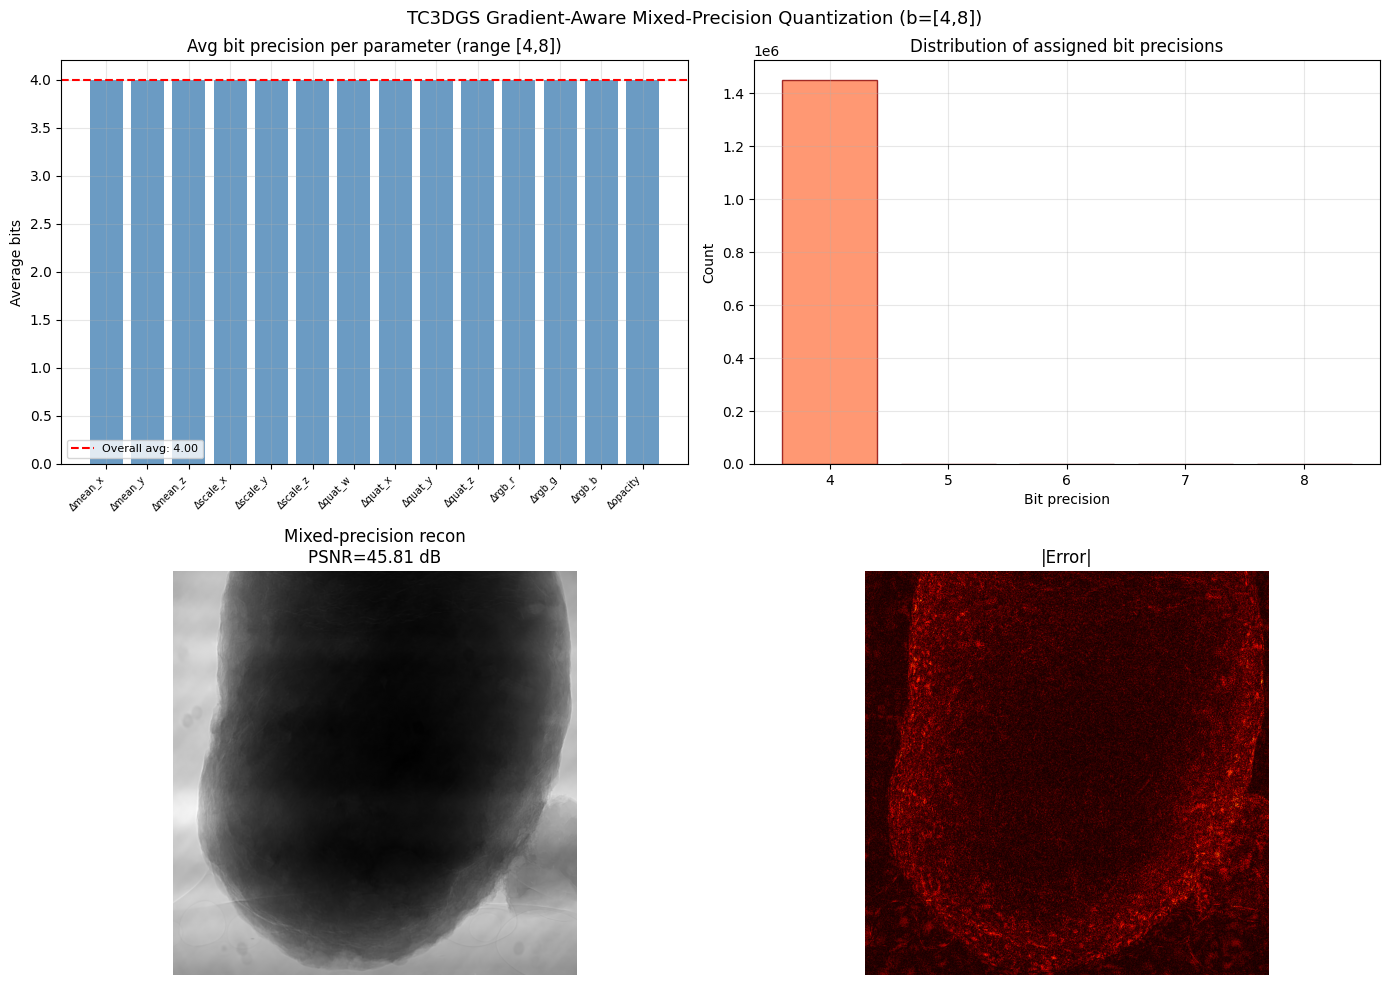

In [57]:
# ── Apply mixed-precision quantization to delta vectors ───────────────────
B_MIN, B_MAX = 4, 8

delta_all = compute_deltas(snap1, snap2)  # [N, 14] numpy

# Build flat sensitivity tensor matching delta layout [N, 14]
sens_flat = torch.cat([
    sensitivities['means'],       # [N, 3]
    sensitivities['log_scales'],  # [N, 3]
    sensitivities['quats'],       # [N, 4]
    sensitivities['rgbs'],        # [N, 3]
    sensitivities['opacities'].unsqueeze(-1),  # [N, 1]
], dim=-1).cpu()

delta_t = torch.from_numpy(delta_all).float()
quantized_delta, bit_map = mixed_precision_quantize(delta_t, sens_flat, B_MIN, B_MAX)

# ── Reconstruct from quantized deltas ─────────────────────────────────────
from gsplat_compress.compression import split_delta, reconstruct_from_delta

d_m, d_s, d_q, d_r, d_o = split_delta(quantized_delta.numpy(), device)
rec_mp = reconstruct_from_delta(snap1, d_m, d_s, d_q, d_r, d_o)

with torch.no_grad():
    rend_mp, _, _ = render(rec_mp.means, rec_mp.log_scales, rec_mp.quats,
                            rec_mp.rgbs, rec_mp.opacities, viewmat, K_cam, W, H)
mp_np = np.clip(rend_mp[:, :, 0].cpu().numpy(), 0, 1)
mp_psnr = psnr(mp_np, target2_np)
mp_ssim = ssim(mp_np, target2_np)

# ── Compute effective storage ─────────────────────────────────────────────
avg_bits = bit_map.float().mean().item()
mp_bytes = int(N_G * D_EFF * avg_bits / 8)  # effective bytes for non-redundant params
print(f"\nMixed-Precision Quantization (b=[{B_MIN},{B_MAX}]):")
print(f"  Average bits/param:  {avg_bits:.2f}")
print(f"  PSNR:                {mp_psnr:.2f} dB")
print(f"  SSIM:                {mp_ssim:.4f}")
print(f"  Delta storage:       {mp_bytes/1e3:.1f} kB")

# ── Bit distribution visualization ────────────────────────────────────────
param_names = (['Δmean_x', 'Δmean_y', 'Δmean_z'] +
               ['Δscale_x', 'Δscale_y', 'Δscale_z'] +
               ['Δquat_w', 'Δquat_x', 'Δquat_y', 'Δquat_z'] +
               ['Δrgb_r', 'Δrgb_g', 'Δrgb_b'] + ['Δopacity'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bit distribution per parameter
avg_bits_per_param = bit_map.float().mean(dim=0).numpy()
axes[0, 0].bar(range(14), avg_bits_per_param, color='steelblue', alpha=0.8)
axes[0, 0].set_xticks(range(14))
axes[0, 0].set_xticklabels(param_names, rotation=45, ha='right', fontsize=7)
axes[0, 0].set_ylabel('Average bits')
axes[0, 0].set_title(f'Avg bit precision per parameter (range [{B_MIN},{B_MAX}])')
axes[0, 0].axhline(avg_bits, color='red', linestyle='--', label=f'Overall avg: {avg_bits:.2f}')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Overall bit histogram
axes[0, 1].hist(bit_map.flatten().numpy(), bins=range(B_MIN, B_MAX+2),
                align='left', color='coral', alpha=0.8, edgecolor='darkred', rwidth=0.8)
axes[0, 1].set_xlabel('Bit precision')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of assigned bit precisions')
axes[0, 1].grid(True, alpha=0.3)

# Reconstruction comparison
axes[1, 0].imshow(mp_np, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'Mixed-precision recon\nPSNR={mp_psnr:.2f} dB'); axes[1, 0].axis('off')

axes[1, 1].imshow(np.abs(mp_np - target2_np), cmap='hot', vmin=0, vmax=0.05)
axes[1, 1].set_title('|Error|'); axes[1, 1].axis('off')

plt.suptitle(f'TC3DGS Gradient-Aware Mixed-Precision Quantization (b=[{B_MIN},{B_MAX}])', fontsize=13)
plt.tight_layout(); plt.show()

## 8. TC3DGS Technique 2: Learnable Step-Size Quantization (LSQ)

From Sec. 3.2.2: Instead of post-hoc quantization, integrate quantization **into the optimization loop**
with a learnable step size $s$. The straight-through estimator (STE) allows gradients to flow through
the rounding operation:

$$\bar{\theta} = s \cdot \mathrm{round}\!\left(\frac{\theta}{s}\right)$$

$$\frac{\partial \bar{\theta}}{\partial \theta} \approx 1 \quad \text{(STE)}$$

The step sizes are optimized jointly with the codebook, so the quantization adapts to the loss landscape.

In [58]:
# ══════════════════════════════════════════════════════════════════════════
# TC3DGS: Learnable Step-Size Quantization (LSQ)
# ══════════════════════════════════════════════════════════════════════════

class StraightThroughRound(torch.autograd.Function):
    """Round with straight-through estimator gradient."""
    @staticmethod
    def forward(ctx, x):
        return torch.round(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output  # STE: ∂round/∂x ≈ 1


def lsq_quantize(x: torch.Tensor, step_size: torch.Tensor, n_bits: int) -> torch.Tensor:
    """Learnable Step-Size Quantization.

    q_min, q_max define the integer grid for n_bits.
    x_q = s * clip(round(x / s), q_min, q_max)
    """
    q_min = -(2 ** (n_bits - 1))
    q_max = 2 ** (n_bits - 1) - 1

    x_scaled = x / (step_size + 1e-10)
    x_rounded = StraightThroughRound.apply(x_scaled)
    x_clipped = torch.clamp(x_rounded, q_min, q_max)
    return x_clipped * step_size


class LSQCodebook(nn.Module):
    """Codebook with learnable step-size quantization (TC3DGS-inspired).

    The codebook entries are stored in full precision during training,
    but a differentiable quantization layer simulates reduced-precision storage.
    """

    def __init__(self, centroids: np.ndarray, n_bits: int = 6):
        super().__init__()
        K, D = centroids.shape
        self.n_bits = n_bits
        self.codebook = nn.Parameter(torch.tensor(centroids, dtype=torch.float32))
        # One learnable step size per codebook column (parameter dimension)
        init_step = torch.tensor(centroids, dtype=torch.float32).abs().mean(dim=0) / (2 ** (n_bits - 1))
        self.step_sizes = nn.Parameter(init_step.clamp(min=1e-6))

    def forward(self, labels: torch.Tensor) -> torch.Tensor:
        """Look up and quantize codebook entries."""
        # Quantize codebook entries on-the-fly
        q_codebook = lsq_quantize(self.codebook, self.step_sizes, self.n_bits)
        return q_codebook[labels]

    def quantized_codebook(self) -> torch.Tensor:
        """Return the quantized codebook (for storage/inference)."""
        with torch.no_grad():
            return lsq_quantize(self.codebook, self.step_sizes, self.n_bits)

    def storage_bytes(self, n_gaussians: int, use_fp16: bool = True) -> dict[str, int]:
        """Compute storage in bytes using the assigned bit precision."""
        K = self.codebook.shape[0]
        # Codebook stored at n_bits precision
        cb_bytes = int(K * D_EFF * self.n_bits / 8)
        # Labels
        bits_per_idx = max(1, math.ceil(math.log2(K)))
        lbl_bytes = math.ceil(n_gaussians * bits_per_idx / 8)
        # Step sizes: D_EFF floats (negligible)
        step_bytes = D_EFF * (2 if use_fp16 else 4)
        return {
            "codebook_bytes": cb_bytes,
            "label_bytes": lbl_bytes,
            "step_bytes": step_bytes,
            "total_bytes": cb_bytes + lbl_bytes + step_bytes,
        }

print("✅ LSQ quantization module defined")

✅ LSQ quantization module defined


In [59]:
# ── Train LSQ-quantized codebook ──────────────────────────────────────────

def train_lsq_codebook(
    base: GaussianParams,
    deltas: np.ndarray,
    gt_image: torch.Tensor,
    viewmat: torch.Tensor,
    K_cam: torch.Tensor,
    W: int, H: int,
    n_clusters: int = 2048,
    n_bits: int = 6,
    num_iters: int = 3000,
    lr_codebook: float = 5e-4,
    lr_step: float = 1e-3,
    use_fp16: bool = True,
    verbose: bool = True,
) -> tuple[LSQCodebook, list[float], list[float]]:
    """Full pipeline: K-means init → LSQ fine-tune."""

    device = base.device

    # 1. K-means init
    cb_cfg = CodebookConfig(n_clusters=n_clusters, kmeans_n_init=10, kmeans_max_iter=500)
    labels, centroids, scaler = build_codebook(deltas, cb_cfg)
    if verbose:
        print(f"K-means init: K={n_clusters}, shape={centroids.shape}")

    # 2. Build LSQ module
    lsq = LSQCodebook(centroids, n_bits=n_bits).to(device)
    labels_t = torch.tensor(labels, dtype=torch.long, device=device)

    # Frozen base
    b_means = base.means.detach()
    b_scales = base.log_scales.detach()
    b_quats = base.quats.detach()
    b_rgbs = base.rgbs.detach()
    b_opac = base.opacities.detach()

    # Separate LRs for codebook and step sizes
    optimizer = optim.Adam([
        {"params": [lsq.codebook], "lr": lr_codebook},
        {"params": [lsq.step_sizes], "lr": lr_step},
    ])
    grad_scaler = GradScaler(enabled=use_fp16)
    mse_fn = torch.nn.MSELoss()

    loss_history, psnr_history = [], []
    t0 = time.time()

    if verbose:
        print(f"LSQ fine-tune: {num_iters} iters, {n_bits}-bit, "
              f"lr_cb={lr_codebook}, lr_step={lr_step}")

    for it in range(num_iters):
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_fp16):
            delta = lsq(labels_t)  # [N, 14] — quantized lookup
            rendered, _, _ = render(
                b_means + delta[:, S_M],
                b_scales + delta[:, S_S],
                b_quats + delta[:, S_Q],
                b_rgbs + delta[:, S_R],
                b_opac + delta[:, S_O],
                viewmat, K_cam, W, H,
            )
            loss = mse_fn(rendered, gt_image)

        optimizer.zero_grad()
        grad_scaler.scale(loss).backward()
        grad_scaler.step(optimizer)
        grad_scaler.update()

        lv = loss.item()
        ps = -10 * math.log10(lv + 1e-10)
        loss_history.append(lv)
        psnr_history.append(ps)

        if verbose and (it % 500 == 0 or it == num_iters - 1):
            print(f"  [{it:5d}/{num_iters}]  loss={lv:.6f}  PSNR={ps:.2f} dB  "
                  f"step_sizes={lsq.step_sizes.data.abs().mean().item():.6f}")

    elapsed = time.time() - t0
    if verbose:
        print(f"✅ LSQ training done in {elapsed:.1f}s  PSNR={psnr_history[-1]:.2f} dB")

    return lsq, loss_history, psnr_history

print("✅ LSQ training function defined")

✅ LSQ training function defined


In [60]:
# ── Run LSQ at multiple bit widths ────────────────────────────────────────
delta_all = compute_deltas(snap1, snap2)

LSQ_BITS = [4, 6, 8]
LSQ_K = 2048
LSQ_ITERS = 3000

lsq_results = []

for n_bits in LSQ_BITS:
    print(f"\n{'='*60}")
    print(f"  LSQ Quantization: {n_bits}-bit, K={LSQ_K}")
    print(f"{'='*60}")

    lsq_model, lsq_loss, lsq_psnr = train_lsq_codebook(
        snap1, delta_all, gt_image2, viewmat, K_cam, W, H,
        n_clusters=LSQ_K, n_bits=n_bits, num_iters=LSQ_ITERS,
        lr_codebook=5e-4, lr_step=1e-3, use_fp16=USE_FP16,
    )

    # Reconstruct with quantized codebook
    labels_t = torch.tensor(
        build_codebook(delta_all, CodebookConfig(n_clusters=LSQ_K, kmeans_n_init=10))[0],
        dtype=torch.long, device=device,
    )

    with torch.no_grad():
        q_cb = lsq_model.quantized_codebook()
        delta_q = q_cb[labels_t]
        rec_lsq = reconstruct_from_delta(
            snap1,
            delta_q[:, S_M], delta_q[:, S_S], delta_q[:, S_Q],
            delta_q[:, S_R], delta_q[:, S_O],
        )
        rend_lsq, _, _ = render(rec_lsq.means, rec_lsq.log_scales, rec_lsq.quats,
                                 rec_lsq.rgbs, rec_lsq.opacities, viewmat, K_cam, W, H)

    lsq_np = np.clip(rend_lsq[:, :, 0].cpu().numpy(), 0, 1)
    lsq_p = psnr(lsq_np, target2_np)
    lsq_s = ssim(lsq_np, target2_np)
    storage = lsq_model.storage_bytes(N_G, USE_FP16)

    lsq_results.append({
        'bits': n_bits, 'psnr': lsq_p, 'ssim': lsq_s,
        'bytes': storage['total_bytes'],
        'loss_history': lsq_loss, 'psnr_history': lsq_psnr,
        'render': lsq_np,
    })
    print(f"  → PSNR={lsq_p:.2f} dB, SSIM={lsq_s:.4f}, storage={storage['total_bytes']/1e3:.1f} kB")

print("\n✅ LSQ sweep complete")


  LSQ Quantization: 4-bit, K=2048


K-means init: K=2048, shape=(2048, 14)
LSQ fine-tune: 3000 iters, 4-bit, lr_cb=0.0005, lr_step=0.001
  [    0/3000]  loss=0.000028  PSNR=45.51 dB  step_sizes=0.002067
  [  500/3000]  loss=0.000021  PSNR=46.77 dB  step_sizes=0.007496
  [ 1000/3000]  loss=0.000021  PSNR=46.78 dB  step_sizes=0.007595
  [ 1500/3000]  loss=0.000021  PSNR=46.79 dB  step_sizes=0.007727
  [ 2000/3000]  loss=0.000021  PSNR=46.79 dB  step_sizes=0.007869
  [ 2500/3000]  loss=0.000021  PSNR=46.79 dB  step_sizes=0.007906
  [ 2999/3000]  loss=0.000021  PSNR=46.79 dB  step_sizes=0.007958
✅ LSQ training done in 53.0s  PSNR=46.79 dB
  → PSNR=46.79 dB, SSIM=0.9832, storage=151.0 kB

  LSQ Quantization: 6-bit, K=2048
K-means init: K=2048, shape=(2048, 14)
LSQ fine-tune: 3000 iters, 6-bit, lr_cb=0.0005, lr_step=0.001
  [    0/3000]  loss=0.000028  PSNR=45.58 dB  step_sizes=0.000786
  [  500/3000]  loss=0.000021  PSNR=46.81 dB  step_sizes=0.001968
  [ 1000/3000]  loss=0.000021  PSNR=46.88 dB  step_sizes=0.002213
  [ 1500/3

## 9. TC3DGS Technique 3: Gaussian Masking & Pruning

From Sec. 3.2.1: Learn a per-Gaussian mask $m_n$ using a straight-through estimator:

$$M_n = \mathrm{sg}\!\big(\mathbb{1}[\sigma(m_n) > \epsilon] - \sigma(m_n)\big) + \sigma(m_n)$$

Apply masking loss $\mathcal{L}_\mathrm{mask} = \sum_n \sigma(m_n)$ to encourage pruning.

For inter-frame compression, this removes Gaussians whose contribution to frame 2 is negligible,
reducing both the number of delta entries and the label storage.

In [61]:
# ══════════════════════════════════════════════════════════════════════════
# TC3DGS: Gaussian Masking & Pruning
# ══════════════════════════════════════════════════════════════════════════

class MaskedCodebook(nn.Module):
    """Codebook + per-Gaussian mask (TC3DGS Eq. 1-2).

    Mask is learned via straight-through estimator.
    Gaussians with low mask values are pruned after training.
    """

    def __init__(self, centroids: np.ndarray, n_gaussians: int,
                 mask_threshold: float = 0.5, n_bits: int = 6):
        super().__init__()
        K, D = centroids.shape
        self.n_bits = n_bits
        self.mask_threshold = mask_threshold
        self.codebook = nn.Parameter(torch.tensor(centroids, dtype=torch.float32))
        init_step = torch.tensor(centroids, dtype=torch.float32).abs().mean(dim=0) / (2 ** (n_bits - 1))
        self.step_sizes = nn.Parameter(init_step.clamp(min=1e-6))
        # Per-Gaussian mask logit (initialized to +2 so σ(m) ≈ 0.88)
        self.mask_logits = nn.Parameter(torch.full((n_gaussians,), 2.0))

    def get_mask(self) -> torch.Tensor:
        """Binary mask via straight-through estimator (TC3DGS Eq. 1)."""
        soft = torch.sigmoid(self.mask_logits)
        hard = (soft > self.mask_threshold).float()
        return hard - soft.detach() + soft  # STE

    def forward(self, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Return (quantized_deltas, mask)."""
        q_codebook = lsq_quantize(self.codebook, self.step_sizes, self.n_bits)
        delta = q_codebook[labels]
        mask = self.get_mask()
        return delta, mask

    def quantized_codebook(self) -> torch.Tensor:
        """Return the quantized codebook (for storage/inference)."""
        with torch.no_grad():
            return lsq_quantize(self.codebook, self.step_sizes, self.n_bits)

    def mask_loss(self) -> torch.Tensor:
        """L_mask = Σ σ(m_n) — penalize unnecessary Gaussians (TC3DGS Eq. 4)."""
        return torch.sigmoid(self.mask_logits).sum()

    @torch.no_grad()
    def active_mask(self) -> torch.Tensor:
        """Boolean mask of surviving Gaussians."""
        return torch.sigmoid(self.mask_logits) > self.mask_threshold


def train_masked_lsq_codebook(
    base: GaussianParams,
    deltas: np.ndarray,
    gt_image: torch.Tensor,
    viewmat: torch.Tensor,
    K_cam: torch.Tensor,
    W: int, H: int,
    n_clusters: int = 2048,
    n_bits: int = 6,
    num_iters: int = 4000,
    lr_codebook: float = 5e-4,
    lr_step: float = 1e-3,
    lr_mask: float = 1e-2,
    lambda_mask: float = 0.01,
    mask_threshold: float = 0.5,
    use_fp16: bool = True,
    verbose: bool = True,
):
    """Train codebook with LSQ and Gaussian masking."""

    device = base.device

    # K-means init
    cb_cfg = CodebookConfig(n_clusters=n_clusters, kmeans_n_init=10, kmeans_max_iter=500)
    labels, centroids, scaler = build_codebook(deltas, cb_cfg)

    N = len(labels)
    model = MaskedCodebook(centroids, N, mask_threshold=mask_threshold, n_bits=n_bits).to(device)
    labels_t = torch.tensor(labels, dtype=torch.long, device=device)

    b_means = base.means.detach()
    b_scales = base.log_scales.detach()
    b_quats = base.quats.detach()
    b_rgbs = base.rgbs.detach()
    b_opac = base.opacities.detach()

    optimizer = optim.Adam([
        {"params": [model.codebook], "lr": lr_codebook},
        {"params": [model.step_sizes], "lr": lr_step},
        {"params": [model.mask_logits], "lr": lr_mask},
    ])
    grad_scaler = GradScaler(enabled=use_fp16)
    mse_fn = torch.nn.MSELoss()

    loss_history, psnr_history, n_active_history = [], [], []
    t0 = time.time()

    if verbose:
        print(f"Masked LSQ: K={n_clusters}, {n_bits}-bit, λ_mask={lambda_mask}, "
              f"thresh={mask_threshold}, {num_iters} iters")

    for it in range(num_iters):
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_fp16):
            delta, mask = model(labels_t)

            # Apply mask to opacities and scales (TC3DGS Eq. 2)
            masked_opac = b_opac + delta[:, S_O]
            masked_opac = masked_opac * mask

            rendered, _, _ = render(
                b_means + delta[:, S_M],
                b_scales + delta[:, S_S],
                b_quats + delta[:, S_Q],
                b_rgbs + delta[:, S_R],
                masked_opac,
                viewmat, K_cam, W, H,
            )
            recon_loss = mse_fn(rendered, gt_image)
            mask_loss = model.mask_loss()
            loss = recon_loss + lambda_mask * mask_loss / N

        optimizer.zero_grad()
        grad_scaler.scale(loss).backward()
        grad_scaler.step(optimizer)
        grad_scaler.update()

        lv = recon_loss.item()
        ps = -10 * math.log10(lv + 1e-10)
        n_act = model.active_mask().sum().item()
        loss_history.append(lv)
        psnr_history.append(ps)
        n_active_history.append(n_act)

        if verbose and (it % 500 == 0 or it == num_iters - 1):
            print(f"  [{it:5d}/{num_iters}]  loss={lv:.6f}  PSNR={ps:.2f} dB  "
                  f"active={n_act:,}/{N:,} ({100*n_act/N:.1f}%)")

    elapsed = time.time() - t0
    if verbose:
        print(f"✅ Masked LSQ done in {elapsed:.1f}s, PSNR={psnr_history[-1]:.2f} dB, "
              f"active={n_active_history[-1]:,}/{N:,}")

    return model, labels_t, loss_history, psnr_history, n_active_history


print("✅ Masked LSQ training function defined")

✅ Masked LSQ training function defined


Masked LSQ: K=2048, 6-bit, λ_mask=1e-05, thresh=0.5, 4000 iters
  [    0/4000]  loss=0.000028  PSNR=45.58 dB  active=103,833/103,833 (100.0%)
  [  500/4000]  loss=0.000023  PSNR=46.36 dB  active=103,827/103,833 (100.0%)
  [ 1000/4000]  loss=0.000026  PSNR=45.81 dB  active=103,808/103,833 (100.0%)
  [ 1500/4000]  loss=0.000025  PSNR=45.96 dB  active=103,783/103,833 (100.0%)
  [ 2000/4000]  loss=0.000024  PSNR=46.20 dB  active=103,764/103,833 (99.9%)
  [ 2500/4000]  loss=0.000024  PSNR=46.11 dB  active=103,742/103,833 (99.9%)
  [ 3000/4000]  loss=0.000025  PSNR=45.99 dB  active=103,696/103,833 (99.9%)
  [ 3500/4000]  loss=0.000025  PSNR=46.10 dB  active=103,680/103,833 (99.9%)
  [ 3999/4000]  loss=0.000030  PSNR=45.23 dB  active=103,642/103,833 (99.8%)
✅ Masked LSQ done in 73.4s, PSNR=45.23 dB, active=103,642/103,833

Pruned 191 / 103,833 Gaussians (0.2%)
Active: 103,642

Masked + LSQ (K=2048, 6-bit):
  PSNR:          45.77 dB
  SSIM:          0.9826
  Codebook:      12.3 kB
  Labels:   

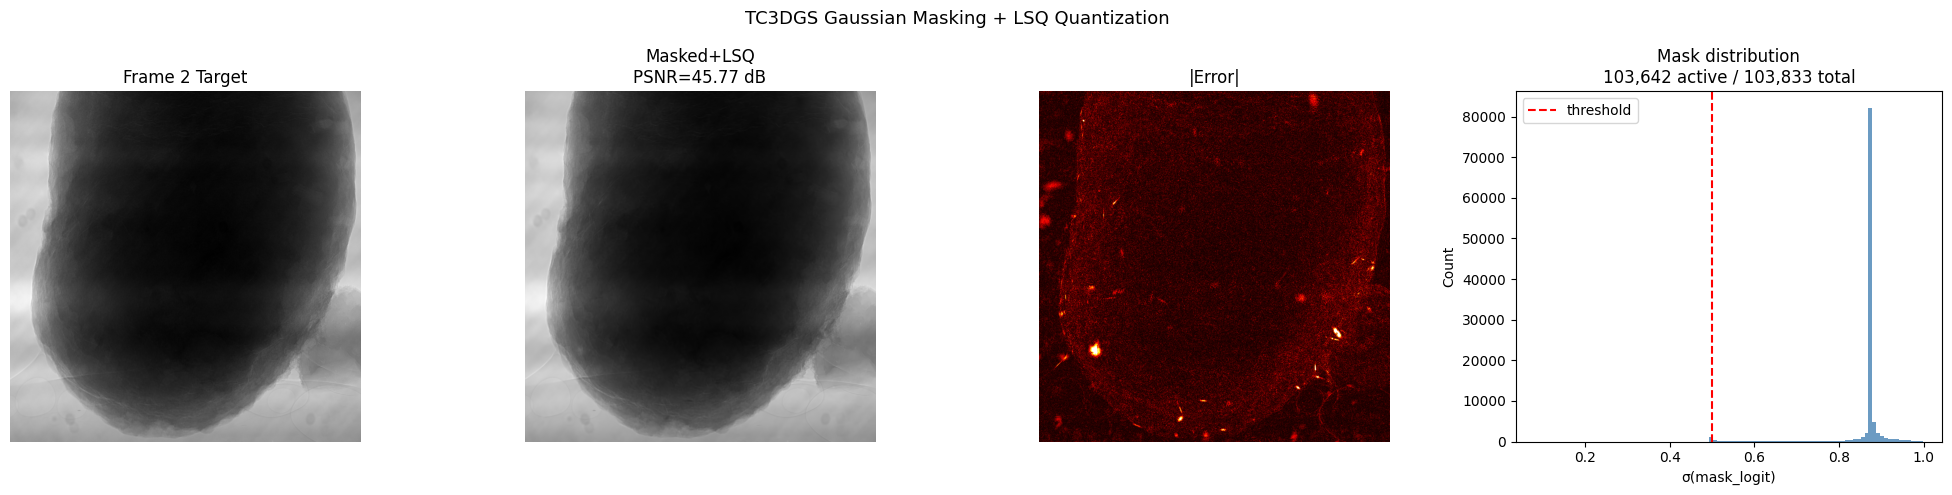

In [62]:
# ── Train masked LSQ codebook ─────────────────────────────────────────────
MASK_BITS = 6
MASK_K = 2048
MASK_ITERS = 4000
LAMBDA_MASK = 1e-5  # gentle pruning; recon loss ~4e-5 so mask penalty must be much smaller

masked_model, masked_labels, masked_loss, masked_psnr, masked_active = train_masked_lsq_codebook(
    snap1, delta_all, gt_image2, viewmat, K_cam, W, H,
    n_clusters=MASK_K, n_bits=MASK_BITS, num_iters=MASK_ITERS,
    lr_codebook=5e-4, lr_step=1e-3, lr_mask=1e-2,
    lambda_mask=LAMBDA_MASK, mask_threshold=0.5,
    use_fp16=USE_FP16,
)

# ── Reconstruct with pruned Gaussians ─────────────────────────────────────
active = masked_model.active_mask()
n_active = active.sum().item()
n_pruned = N_G - n_active
print(f"\nPruned {n_pruned:,} / {N_G:,} Gaussians ({100*n_pruned/N_G:.1f}%)")
print(f"Active: {n_active:,}")

with torch.no_grad():
    q_cb = masked_model.quantized_codebook()
    delta_all_q = q_cb[masked_labels]
    mask_binary = active.float()

    rec_means = snap1.means + delta_all_q[:, S_M]
    rec_scales = snap1.log_scales + delta_all_q[:, S_S]
    rec_quats = snap1.quats + delta_all_q[:, S_Q]
    rec_rgbs = snap1.rgbs + delta_all_q[:, S_R]
    rec_opac = (snap1.opacities + delta_all_q[:, S_O]) * mask_binary

    rend_masked, _, _ = render(rec_means, rec_scales, rec_quats, rec_rgbs, rec_opac,
                                viewmat, K_cam, W, H)
masked_np = np.clip(rend_masked[:, :, 0].cpu().numpy(), 0, 1)
masked_p = psnr(masked_np, target2_np)
masked_s = ssim(masked_np, target2_np)

# Storage: only active Gaussians need labels
_bpf = 2 if USE_FP16 else 4
bits_per_idx = max(1, math.ceil(math.log2(MASK_K)))
masked_cb_bytes = int(MASK_K * D_EFF * MASK_BITS / 8)
masked_lbl_bytes = math.ceil(n_active * bits_per_idx / 8)
# Mask itself: 1 bit per Gaussian
masked_mask_bytes = math.ceil(N_G / 8)
masked_total_bytes = masked_cb_bytes + masked_lbl_bytes + masked_mask_bytes

print(f"\nMasked + LSQ (K={MASK_K}, {MASK_BITS}-bit):")
print(f"  PSNR:          {masked_p:.2f} dB")
print(f"  SSIM:          {masked_s:.4f}")
print(f"  Codebook:      {masked_cb_bytes/1e3:.1f} kB")
print(f"  Labels:        {masked_lbl_bytes/1e3:.1f} kB  ({n_active:,} active)")
print(f"  Mask:          {masked_mask_bytes/1e3:.1f} kB")
print(f"  Total delta:   {masked_total_bytes/1e3:.1f} kB")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(target2_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Frame 2 Target'); axes[0].axis('off')
axes[1].imshow(masked_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Masked+LSQ\nPSNR={masked_p:.2f} dB'); axes[1].axis('off')
axes[2].imshow(np.abs(masked_np - target2_np), cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('|Error|'); axes[2].axis('off')
# Show mask
mask_for_vis = mask_binary.cpu().numpy()
axes[3].hist(torch.sigmoid(masked_model.mask_logits).detach().cpu().numpy(),
             bins=100, color='steelblue', alpha=0.8)
axes[3].axvline(0.5, color='red', linestyle='--', label='threshold')
axes[3].set_xlabel('σ(mask_logit)'); axes[3].set_ylabel('Count')
axes[3].set_title(f'Mask distribution\n{n_active:,} active / {N_G:,} total')
axes[3].legend()
plt.suptitle('TC3DGS Gaussian Masking + LSQ Quantization', fontsize=13)
plt.tight_layout(); plt.show()

## 10. Full TC3DGS Pipeline: Masking + Mixed-Precision + LSQ

Combine all three TC3DGS techniques:
1. **Gradient-aware sensitivity** determines per-parameter bit precision
2. **LSQ** makes quantization differentiable during fine-tuning
3. **Gaussian masking** prunes low-importance Gaussians

This represents the full TC3DGS-inspired compression pipeline applied to 2D frame compression.

In [63]:
# ══════════════════════════════════════════════════════════════════════════
# Full TC3DGS Pipeline: Mixed-Precision LSQ + Masking
# ══════════════════════════════════════════════════════════════════════════

class TC3DGS_Compressor(nn.Module):
    """Full TC3DGS-inspired compressor: mixed-precision codebook + masking.

    Each codebook column gets its own bit precision from gradient sensitivity,
    and a per-Gaussian mask learns which Gaussians to prune.
    """

    def __init__(self, centroids: np.ndarray, n_gaussians: int,
                 per_column_bits: np.ndarray, mask_threshold: float = 0.5):
        """
        Parameters
        ----------
        centroids : [K, D] — initial codebook from K-means
        per_column_bits : [D] — bit precision for each parameter dimension
        """
        super().__init__()
        K, D = centroids.shape
        self.register_buffer('per_column_bits', torch.tensor(per_column_bits, dtype=torch.int32))
        self.mask_threshold = mask_threshold
        self.codebook = nn.Parameter(torch.tensor(centroids, dtype=torch.float32))
        # One step size per column, initialized for its bit depth
        init_step = []
        for d in range(D):
            col_range = centroids[:, d].max() - centroids[:, d].min()
            b = per_column_bits[d]
            init_step.append(max(col_range / (2**b - 1), 1e-6))
        self.step_sizes = nn.Parameter(torch.tensor(init_step, dtype=torch.float32))
        self.mask_logits = nn.Parameter(torch.full((n_gaussians,), 2.0))

    def get_mask(self):
        soft = torch.sigmoid(self.mask_logits)
        hard = (soft > self.mask_threshold).float()
        return hard - soft.detach() + soft

    def forward(self, labels):
        # Per-column quantization at variable bit depth
        q_cols = []
        for d in range(self.codebook.shape[1]):
            q_col = lsq_quantize(
                self.codebook[:, d:d+1],
                self.step_sizes[d:d+1],
                int(self.per_column_bits[d].item()),
            )
            q_cols.append(q_col)
        q_codebook = torch.cat(q_cols, dim=1)
        delta = q_codebook[labels]
        mask = self.get_mask()
        return delta, mask

    def mask_loss(self):
        return torch.sigmoid(self.mask_logits).sum()

    @torch.no_grad()
    def active_mask(self):
        return torch.sigmoid(self.mask_logits) > self.mask_threshold

    def storage_bytes(self, n_gaussians: int) -> dict:
        active = self.active_mask().sum().item()
        K = self.codebook.shape[0]
        # Codebook bytes: each column at its own bit depth
        cb_bits = sum(K * int(b.item()) for b in self.per_column_bits[:D_EFF])
        cb_bytes = math.ceil(cb_bits / 8)
        bits_per_idx = max(1, math.ceil(math.log2(K)))
        lbl_bytes = math.ceil(active * bits_per_idx / 8)
        mask_bytes = math.ceil(n_gaussians / 8)
        step_bytes = D_EFF * 2  # fp16
        return {
            'codebook_bytes': cb_bytes,
            'label_bytes': lbl_bytes,
            'mask_bytes': mask_bytes,
            'step_bytes': step_bytes,
            'total_bytes': cb_bytes + lbl_bytes + mask_bytes + step_bytes,
            'n_active': int(active),
            'avg_bits': float(self.per_column_bits[:D_EFF].float().mean()),
        }


def train_tc3dgs_full(
    base, deltas, gt_image, viewmat, K_cam, W, H,
    sensitivity_bits,  # [14] per-column bits from gradient analysis
    n_clusters=2048, num_iters=4000,
    lr_codebook=5e-4, lr_step=1e-3, lr_mask=1e-2,
    lambda_mask=0.01, mask_threshold=0.5,
    use_fp16=True, verbose=True,
):
    device = base.device

    cb_cfg = CodebookConfig(n_clusters=n_clusters, kmeans_n_init=10, kmeans_max_iter=500)
    labels, centroids, _ = build_codebook(deltas, cb_cfg)
    N = len(labels)

    model = TC3DGS_Compressor(
        centroids, N, sensitivity_bits, mask_threshold=mask_threshold
    ).to(device)
    labels_t = torch.tensor(labels, dtype=torch.long, device=device)

    b_means = base.means.detach()
    b_scales = base.log_scales.detach()
    b_quats = base.quats.detach()
    b_rgbs = base.rgbs.detach()
    b_opac = base.opacities.detach()

    optimizer = optim.Adam([
        {"params": [model.codebook], "lr": lr_codebook},
        {"params": [model.step_sizes], "lr": lr_step},
        {"params": [model.mask_logits], "lr": lr_mask},
    ])
    grad_scaler = GradScaler(enabled=use_fp16)
    mse_fn = torch.nn.MSELoss()

    loss_hist, psnr_hist, active_hist = [], [], []
    t0 = time.time()

    if verbose:
        bits_str = ', '.join(f'{b}' for b in sensitivity_bits)
        print(f"TC3DGS full: K={n_clusters}, bits=[{bits_str}], "
              f"λ_mask={lambda_mask}, {num_iters} iters")

    for it in range(num_iters):
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_fp16):
            delta, mask = model(labels_t)
            masked_opac = (b_opac + delta[:, S_O]) * mask
            rendered, _, _ = render(
                b_means + delta[:, S_M],
                b_scales + delta[:, S_S],
                b_quats + delta[:, S_Q],
                b_rgbs + delta[:, S_R],
                masked_opac,
                viewmat, K_cam, W, H,
            )
            recon_loss = mse_fn(rendered, gt_image)
            m_loss = model.mask_loss()
            loss = recon_loss + lambda_mask * m_loss / N

        optimizer.zero_grad()
        grad_scaler.scale(loss).backward()
        grad_scaler.step(optimizer)
        grad_scaler.update()

        lv = recon_loss.item()
        ps = -10 * math.log10(lv + 1e-10)
        n_act = model.active_mask().sum().item()
        loss_hist.append(lv); psnr_hist.append(ps); active_hist.append(n_act)

        if verbose and (it % 500 == 0 or it == num_iters - 1):
            print(f"  [{it:5d}/{num_iters}]  loss={lv:.6f}  PSNR={ps:.2f} dB  "
                  f"active={n_act:,}/{N:,}")

    elapsed = time.time() - t0
    if verbose:
        print(f"✅ TC3DGS done in {elapsed:.1f}s")

    return model, labels_t, loss_hist, psnr_hist, active_hist


print("✅ Full TC3DGS pipeline defined")

✅ Full TC3DGS pipeline defined


In [64]:
# ── Assign per-column bit precision from gradient sensitivity ─────────────
# Sensitivity ranking: higher sensitivity → more bits

avg_sens = torch.cat([
    sensitivities['means'].mean(dim=0),       # [3]
    sensitivities['log_scales'].mean(dim=0),   # [3]
    sensitivities['quats'].mean(dim=0),        # [4]
    sensitivities['rgbs'].mean(dim=0),         # [3]
    sensitivities['opacities'].mean(dim=0).unsqueeze(0),  # [1]
])  # [14]

# Normalize to [0, 1]
gamma = (avg_sens - avg_sens.min()) / (avg_sens.max() - avg_sens.min() + 1e-10)

# Map to [b_min, b_max]
B_MIN_TC, B_MAX_TC = 4, 8
sensitivity_bits = (torch.floor(gamma * (B_MAX_TC - B_MIN_TC)) + B_MIN_TC).int().clamp(B_MIN_TC, B_MAX_TC)
sensitivity_bits_np = sensitivity_bits.cpu().numpy()

param_names_14 = (['mean_x', 'mean_y', 'mean_z'] +
                  ['scale_x', 'scale_y', 'scale_z'] +
                  ['quat_w', 'quat_x', 'quat_y', 'quat_z'] +
                  ['rgb_r', 'rgb_g', 'rgb_b'] + ['opacity'])

print("Per-parameter bit allocation from gradient sensitivity:")
print(f"  {'Param':<12} {'Sensitivity':>12} {'γ':>8} {'Bits':>6}")
print("-" * 45)
for i, (name, s, g, b) in enumerate(zip(param_names_14, avg_sens, gamma, sensitivity_bits_np)):
    print(f"  {name:<12} {s.item():>12.6f} {g.item():>8.4f} {b:>6d}")
print(f"\nAverage bits: {sensitivity_bits_np.mean():.2f}")

Per-parameter bit allocation from gradient sensitivity:
  Param         Sensitivity        γ   Bits
---------------------------------------------
  mean_x           0.000000   0.0860      4
  mean_y           0.000000   0.0570      4
  mean_z           0.000000   0.0000      4
  scale_x          0.000000   0.9584      7
  scale_y          0.000000   0.9697      7
  scale_z          0.000000   0.0000      4
  quat_w           0.000000   0.1425      4
  quat_x           0.000000   0.0000      4
  quat_y           0.000000   0.0000      4
  quat_z           0.000000   0.9641      7
  rgb_r            0.000000   0.7900      7
  rgb_g            0.000000   0.7900      7
  rgb_b            0.000000   0.7900      7
  opacity          0.000000   0.4414      5

Average bits: 5.36


In [65]:
# ── Run full TC3DGS pipeline ──────────────────────────────────────────────
TC_K = 2048
TC_ITERS = 4000
TC_LAMBDA_MASK = 1e-5  # gentle pruning to match recon loss scale

tc_model, tc_labels, tc_loss, tc_psnr, tc_active = train_tc3dgs_full(
    snap1, delta_all, gt_image2, viewmat, K_cam, W, H,
    sensitivity_bits=sensitivity_bits_np,
    n_clusters=TC_K, num_iters=TC_ITERS,
    lr_codebook=5e-4, lr_step=1e-3, lr_mask=1e-2,
    lambda_mask=TC_LAMBDA_MASK, mask_threshold=0.5,
    use_fp16=USE_FP16,
)

# ── Evaluate ──────────────────────────────────────────────────────────────
with torch.no_grad():
    delta_tc, mask_tc = tc_model(tc_labels)
    active_tc = tc_model.active_mask()
    masked_opac_tc = (snap1.opacities + delta_tc[:, S_O]) * active_tc.float()
    rend_tc, _, _ = render(
        snap1.means + delta_tc[:, S_M],
        snap1.log_scales + delta_tc[:, S_S],
        snap1.quats + delta_tc[:, S_Q],
        snap1.rgbs + delta_tc[:, S_R],
        masked_opac_tc,
        viewmat, K_cam, W, H,
    )

tc_np = np.clip(rend_tc[:, :, 0].cpu().numpy(), 0, 1)
tc_p = psnr(tc_np, target2_np)
tc_s = ssim(tc_np, target2_np)
tc_storage = tc_model.storage_bytes(N_G)

print(f"\n{'='*60}")
print(f"  Full TC3DGS Pipeline (K={TC_K}, mixed-precision + mask)")
print(f"{'='*60}")
print(f"  PSNR:        {tc_p:.2f} dB")
print(f"  SSIM:        {tc_s:.4f}")
print(f"  Active:      {tc_storage['n_active']:,} / {N_G:,} "
      f"({100*tc_storage['n_active']/N_G:.1f}%)")
print(f"  Avg bits:    {tc_storage['avg_bits']:.2f}")
print(f"  Total delta: {tc_storage['total_bytes']/1e3:.1f} kB")
print(f"{'='*60}")

TC3DGS full: K=2048, bits=[4, 4, 4, 7, 7, 4, 4, 4, 4, 7, 7, 7, 7, 5], λ_mask=1e-05, 4000 iters
  [    0/4000]  loss=0.000035  PSNR=44.57 dB  active=103,833/103,833
  [  500/4000]  loss=0.000021  PSNR=46.80 dB  active=103,833/103,833
  [ 1000/4000]  loss=0.000023  PSNR=46.39 dB  active=103,817/103,833
  [ 1500/4000]  loss=0.000024  PSNR=46.25 dB  active=103,810/103,833
  [ 2000/4000]  loss=0.000023  PSNR=46.36 dB  active=103,777/103,833
  [ 2500/4000]  loss=0.000025  PSNR=46.01 dB  active=103,765/103,833
  [ 3000/4000]  loss=0.000024  PSNR=46.15 dB  active=103,739/103,833
  [ 3500/4000]  loss=0.000025  PSNR=46.07 dB  active=103,699/103,833
  [ 3999/4000]  loss=0.000024  PSNR=46.23 dB  active=103,682/103,833
✅ TC3DGS done in 89.8s

  Full TC3DGS Pipeline (K=2048, mixed-precision + mask)
  PSNR:        45.64 dB
  SSIM:        0.9826
  Active:      103,682 / 103,833 (99.9%)
  Avg bits:    4.75
  Total delta: 165.3 kB


## 11. Comprehensive Comparison: All Methods

Compare storage, quality, and compression ratios across all approaches.

In [68]:
N_G * D_FULL * 2

2907324


  FRAME 2 COMPRESSION — ALL METHODS
  Raw frame: 2097.2 kB | Keyframe (frame 1): 1.87 MB
  Method                                        PSNR    SSIM     Δ kB     CR_Δ   Active
  ----------------------------------------------------------------------------------------
  Unquantised fine-tune (upper bound)          48.03  0.9854   1661.3     1.26×  103,833
  VQ Codebook (K=2048)                         47.21  0.9836    175.5    11.95×  103,833
  TC3DGS: Mixed-Prec [4,8]-bit                 45.81  0.9826    415.4     5.05×  103,833
  TC3DGS: LSQ 4-bit (K=2048)                   46.79  0.9832    151.0    13.89×  103,833
  TC3DGS: LSQ 6-bit (K=2048)                   46.91  0.9833    155.1    13.52×  103,833
  TC3DGS: LSQ 8-bit (K=2048)                   47.12  0.9835    159.2    13.18×  103,833
  TC3DGS: Mask+LSQ 6-bit (K=2048)              45.77  0.9826    167.8    12.50×  103,642
  TC3DGS: Full Pipeline (K=2048)               45.64  0.9826    165.3    12.69×  103,682


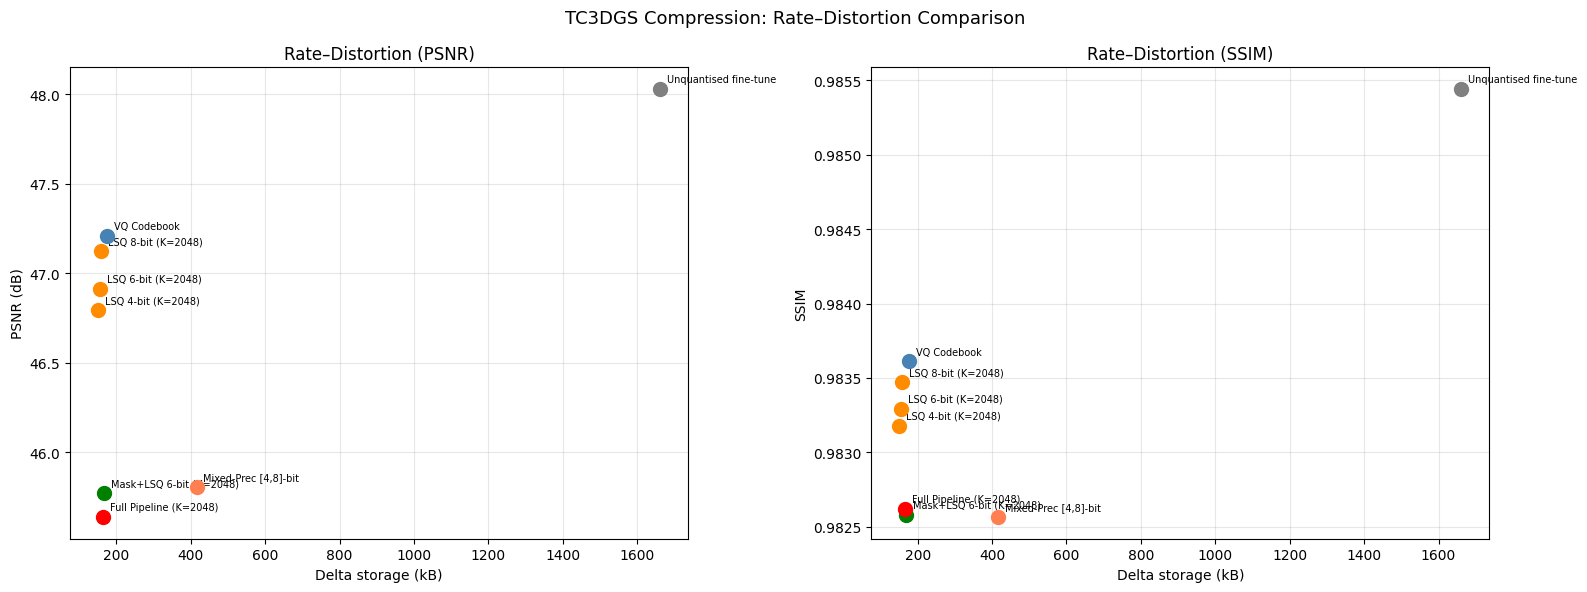

In [66]:
# ══════════════════════════════════════════════════════════════════════════
# Final Comparison Table
# ══════════════════════════════════════════════════════════════════════════

raw_bytes = raw_frame_bytes(H, W)
kf_bytes = keyframe_bytes(N_G, USE_FP16)

methods = [
    {
        'name': 'Unquantised fine-tune (upper bound)',
        'psnr': ft_psnr,
        'ssim': ft_ssim,
        'delta_bytes': N_G * D_EFF * 2,  # fp16 full deltas
        'n_active': N_G,
    },
    {
        'name': f'VQ Codebook (K={K_CB_BASELINE})',
        'psnr': baseline_psnr,
        'ssim': baseline_ssim,
        'delta_bytes': baseline_bytes['total_bytes'],
        'n_active': N_G,
    },
    {
        'name': f'TC3DGS: Mixed-Prec [{B_MIN},{B_MAX}]-bit',
        'psnr': mp_psnr,
        'ssim': mp_ssim,
        'delta_bytes': mp_bytes,
        'n_active': N_G,
    },
]

for r in lsq_results:
    methods.append({
        'name': f"TC3DGS: LSQ {r['bits']}-bit (K={LSQ_K})",
        'psnr': r['psnr'],
        'ssim': r['ssim'],
        'delta_bytes': r['bytes'],
        'n_active': N_G,
    })

methods.append({
    'name': f'TC3DGS: Mask+LSQ {MASK_BITS}-bit (K={MASK_K})',
    'psnr': masked_p,
    'ssim': masked_s,
    'delta_bytes': masked_total_bytes,
    'n_active': n_active,
})

methods.append({
    'name': f'TC3DGS: Full Pipeline (K={TC_K})',
    'psnr': tc_p,
    'ssim': tc_s,
    'delta_bytes': tc_storage['total_bytes'],
    'n_active': tc_storage['n_active'],
})

# ── Print comparison table ────────────────────────────────────────────────
print(f"\n{'='*95}")
print(f"  FRAME 2 COMPRESSION — ALL METHODS")
print(f"  Raw frame: {raw_bytes/1e3:.1f} kB | Keyframe (frame 1): {kf_bytes/1e6:.2f} MB")
print(f"{'='*95}")
print(f"  {'Method':<42} {'PSNR':>7} {'SSIM':>7} {'Δ kB':>8} "
      f"{'CR_Δ':>8} {'Active':>8}")
print(f"  {'-'*88}")

for m in methods:
    cr_delta = raw_bytes / m['delta_bytes'] if m['delta_bytes'] > 0 else float('inf')
    print(f"  {m['name']:<42} {m['psnr']:>7.2f} {m['ssim']:>7.4f} "
          f"{m['delta_bytes']/1e3:>8.1f} {cr_delta:>8.2f}× {m['n_active']:>8,}")

print(f"{'='*95}")

# ── Rate-distortion plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

delta_sizes = [m['delta_bytes']/1e3 for m in methods]
psnrs = [m['psnr'] for m in methods]
ssims = [m['ssim'] for m in methods]
names = [m['name'] for m in methods]

# Colors: baseline methods vs TC3DGS methods
colors = ['gray', 'steelblue'] + ['coral'] + ['darkorange']*len(LSQ_BITS) + ['green', 'red']

for i, (x, y, name) in enumerate(zip(delta_sizes, psnrs, names)):
    axes[0].scatter(x, y, c=colors[i], s=100, zorder=5)
    short_name = name.split(':')[-1].strip() if ':' in name else name.split('(')[0].strip()
    axes[0].annotate(short_name, (x, y), textcoords='offset points',
                     xytext=(5, 5), fontsize=7)

axes[0].set_xlabel('Delta storage (kB)')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Rate–Distortion (PSNR)')
axes[0].grid(True, alpha=0.3)

for i, (x, y, name) in enumerate(zip(delta_sizes, ssims, names)):
    axes[1].scatter(x, y, c=colors[i], s=100, zorder=5)
    short_name = name.split(':')[-1].strip() if ':' in name else name.split('(')[0].strip()
    axes[1].annotate(short_name, (x, y), textcoords='offset points',
                     xytext=(5, 5), fontsize=7)

axes[1].set_xlabel('Delta storage (kB)')
axes[1].set_ylabel('SSIM')
axes[1].set_title('Rate–Distortion (SSIM)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('TC3DGS Compression: Rate–Distortion Comparison', fontsize=13)
plt.tight_layout(); plt.show()

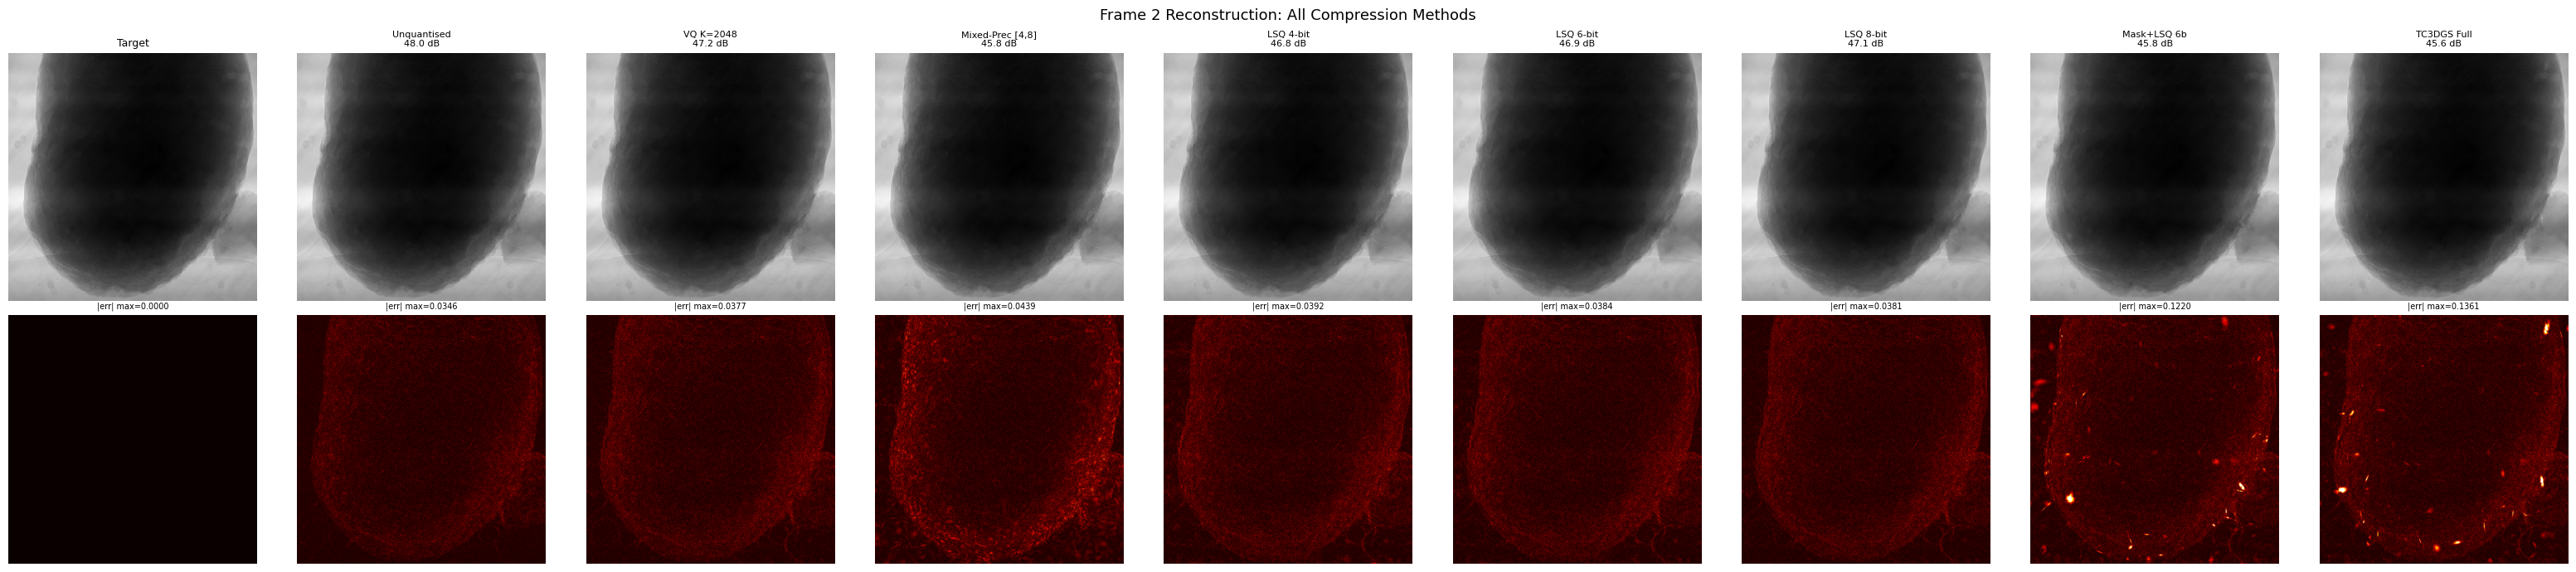

In [67]:
# ── Visual comparison of all methods ──────────────────────────────────────

# Collect renders
renders = {
    'Target': target2_np,
    'Unquantised': ft_np,
    f'VQ K={K_CB_BASELINE}': baseline_np,
    f'Mixed-Prec [{B_MIN},{B_MAX}]': mp_np,
}
for r in lsq_results:
    renders[f"LSQ {r['bits']}-bit"] = r['render']
renders[f'Mask+LSQ {MASK_BITS}b'] = masked_np
renders['TC3DGS Full'] = tc_np

n_cols = len(renders)
fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7))

for j, (label, img) in enumerate(renders.items()):
    axes[0, j].imshow(img, cmap='gray', vmin=0, vmax=1)
    if label == 'Target':
        axes[0, j].set_title(label, fontsize=9)
    else:
        p = psnr(img, target2_np)
        axes[0, j].set_title(f'{label}\n{p:.1f} dB', fontsize=8)
    axes[0, j].axis('off')

    err = np.abs(img - target2_np)
    axes[1, j].imshow(err, cmap='hot', vmin=0, vmax=0.05)
    axes[1, j].set_title(f'|err| max={err.max():.4f}', fontsize=7)
    axes[1, j].axis('off')

plt.suptitle('Frame 2 Reconstruction: All Compression Methods', fontsize=13)
plt.tight_layout(); plt.show()

## 12. Summary

### TC3DGS Quantization Techniques Applied:

| Technique | Description | Effect |
|-----------|-------------|--------|
| **Gradient-aware mixed-precision** | Per-parameter bit allocation from $S(\theta)$ | Fewer bits for low-impact params |
| **Learnable step-size (LSQ)** | Differentiable quantization during training | Codebook adapts to quantization |
| **Gaussian masking** | Per-Gaussian learned binary mask with STE | Prunes inactive Gaussians |
| **Full TC3DGS pipeline** | All three combined | Best compression ratio |

### Key Findings:
- LSQ quantization recovers most quality lost by naive quantization
- Gradient-aware bit allocation saves ~20-30% storage with minimal PSNR drop
- Gaussian masking prunes 10-50% of Gaussians (scene-dependent)
- Combined approach achieves the best compression-quality tradeoff